In [13]:
#Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# Load the dataset
df = pd.read_csv("cleanedcrimedata.csv", low_memory=False)
print("Dataset loaded successfully!")
print("Shape:", df.shape)


Dataset loaded successfully!
Shape: (339346, 65)


In [5]:
df.head()

,Incident Number w/year,Year of Incident,Service Number ID,Watch,Call (911) Problem,Type of Incident,Type Location,Incident Address,Reporting Area,Beat,...,NIBRS Code,NIBRS Group,NIBRS Type,Update Date,X Coordinate,Y Cordinate,Zip Code,City,State,Location1
0,149459-2023,2023,149459-2023-01,1,41/11R - BURG RES IN PROGRESS,CRIM MISCHIEF > OR EQUAL $100 < $750,Apartment Complex/Building,839 S GOOD LATIMER EXPY,2089.0,135.0,...,290,A,Coded,2023-08-23 16:52:39.0000000,2.495803e+06,6.970483e+06,75201.0,DALLAS,TX,"839 S GOOD LATIMER EXPY\nDALLAS, TX 75201\n(32..."
1,119031-2022,2022,119031-2022-01,2,09V - UUMV,UNAUTHORIZED USE OF MOTOR VEH - AUTOMOBILE,Outdoor Area Public/Private,4839 HAAS DR,4309.0,732.0,...,240,A,Not Coded,2022-07-23 20:37:40.0000000,2.501861e+06,6.942006e+06,75216.0,DALLAS,TX,"4839 HAAS DR\nDALLAS, TX 75216\n(32.700112, -9..."
2,208997-2023,2023,208997-2023-01,2,DAEF-DIST ARMED ENCOUNTER FOOT,ASSAULT (AGG) -DEADLY WEAPON,"Highway, Street, Alley ETC",3002 N ST AUGUSTINE RD,1238.0,323.0,...,13A,A,Coded,2023-12-21 15:19:15.0000000,2.535431e+06,6.965638e+06,75227.0,DALLAS,TX,"3002 N ST AUGUSTINE RD\nDALLAS, TX 75227\n(32...."
3,220111-2023,2023,220111-2023-03,3,41/09V - UUMV IN PROGRESS,POSS CONT SUB PEN GRP 1 <1G,Parking (Business),6050 N CENTRAL EXPY,1116.0,141.0,...,35A,A,Coded,2024-01-17 11:36:24.0000000,2.497860e+06,6.992882e+06,75206.0,DALLAS,TX,"6050 N CENTRAL EXPY\nDALLAS, TX 75206\n(32.839..."
4,118827-2022,2022,118827-2022-01,3,58 - ROUTINE INVESTIGATION,"THEFT OF PROP (AUTO ACC) > OR EQUAL $750 <$2,5...",Parking (Business),8687 N CENTRAL EXPY,6012.0,654.0,...,23G,A,Coded,2022-07-05 10:59:04.0000000,2.499513e+06,7.002979e+06,75225.0,DALLAS,TX,"8687 N CENTRAL EXPY\nDALLAS, TX 75225\n(32.868..."


In [15]:
#Checking columns
df.columns.tolist()

['Incident Number w/year',
 'Year of Incident',
 'Service Number ID',
 'Watch',
 'Call (911) Problem',
 'Type of Incident',
 'Type  Location',
 'Incident Address',
 'Reporting Area',
 'Beat',
 'Division',
 'Sector',
 'Council District',
 'Date1 of Occurrence',
 'Year1 of Occurrence',
 'Month1 of Occurence',
 'Day1 of the Week',
 'Time1 of Occurrence',
 'Day1 of the Year',
 'Date2 of Occurrence ',
 'Year2 of Occurrence',
 'Month2 of Occurence',
 'Day2 of the Week',
 'Time2 of Occurrence',
 'Day2 of the Year',
 'Date of Report',
 'Date incident created',
 'Offense Entered Year',
 'Offense Entered Month',
 'Offense Entered Day of the Week',
 'Offense Entered Time',
 'Offense Entered  Date/Time',
 'CFS Number',
 'Call Received Date Time',
 'Call Date Time',
 'Call Cleared Date Time',
 'Call Dispatch Date Time',
 'Person Involvement Type',
 'Victim Type',
 'Responding Officer #1  Badge No',
 'Responding Officer #1  Name',
 'Reporting Officer Badge No',
 'Reviewing Officer Badge No',
 'Eleme

In [7]:
#Checking missing values
df.isnull().sum()

Incident Number w/year    0
Year of Incident          0
Service Number ID         0
Watch                     0
Call (911) Problem        0
                         ..
Y Cordinate               0
Zip Code                  0
City                      0
State                     0
Location1                 0
Length: 65, dtype: int64

In [16]:
#Checking data stats
df.describe()

,Year of Incident,Watch,Reporting Area,Beat,Sector,Year1 of Occurrence,Day1 of the Year,Year2 of Occurrence,Day2 of the Year,Offense Entered Year,Offense Entered Date/Time,Criminal Justice Information Service Code,X Coordinate,Y Cordinate,Zip Code
count,339346.000000,339346.000000,339346.000000,339346.000000,339346.000000,339346.000000,339346.000000,339346.000000,339346.000000,339346.000000,339346.000000,3.393460e+05,3.393460e+05,3.393460e+05,339346.000000
mean,2023.004880,1.962127,3152.164357,408.052510,404.198989,2022.986633,179.495948,2022.997024,179.129994,2023.005242,178.807129,4.927113e+07,2.493266e+06,6.978750e+06,75224.322291
std,0.852878,0.830501,1813.468818,198.752844,198.790100,0.897107,105.835511,0.903786,105.800771,0.852950,105.757989,3.397403e+07,2.115695e+04,3.059181e+04,18.782764
min,2022.000000,1.000000,1001.000000,111.000000,110.000000,1982.000000,1.000000,1900.000000,1.000000,2022.000000,1.000000,7.391108e+06,2.430668e+06,6.912490e+06,75006.000000
25%,2022.000000,1.000000,1258.000000,232.000000,230.000000,2022.000000,88.000000,2022.000000,88.000000,2022.000000,87.000000,2.399019e+07,2.478447e+06,6.957649e+06,75212.000000
50%,2023.000000,2.000000,3058.000000,417.000000,410.000000,2023.000000,180.000000,2023.000000,179.000000,2023.000000,179.000000,2.999004e+07,2.492547e+06,6.975963e+06,75223.000000
75%,2024.000000,3.000000,4315.000000,545.000000,540.000000,2024.000000,270.000000,2024.000000,270.000000,2024.000000,269.000000,1.000000e+08,2.504702e+06,7.001330e+06,75235.000000
max,2026.000000,3.000000,9612.000000,757.000000,750.000000,2025.000000,366.000000,2025.000000,366.000000,2025.000000,366.000000,1.000000e+08,2.579382e+06,7.056512e+06,75287.000000


In [9]:
df["Year1 of Occurrence"].value_counts().sort_index()


Year1 of Occurrence
1982         1
2000        24
2002         2
2003         2
2005         1
2008         3
2009         3
2010         2
2011         3
2012         4
2013         2
2014         6
2015         7
2016        13
2017        20
2018        38
2019        51
2020       116
2021      1252
2022    115652
2023    112913
2024    102873
2025      6358
Name: count, dtype: int64

In [10]:
#Cleaning bad years
df = df[df["Year1 of Occurrence"] >= 2022]
print("Cleaned shape:", df.shape)

Cleaned shape: (337796, 65)


In [11]:
df[df["Year1 of Occurrence"] == 2025]["Month1 of Occurence"].value_counts()

Month1 of Occurence
January    6358
Name: count, dtype: int64

# Exploring crime categories

In [12]:
df["NIBRS Crime Category"].value_counts()

NIBRS Crime Category
MISCELLANEOUS                                 76622
MOTOR VEHICLE THEFT                           71851
LARCENY/ THEFT OFFENSES                       53302
DRUG/ NARCOTIC VIOLATIONS                     22098
ASSAULT OFFENSES                              21986
DESTRUCTION/ DAMAGE/ VANDALISM OF PROPERTY    21326
BURGLARY/ BREAKING & ENTERING                 18773
ALL OTHER OFFENSES                            10728
TRAFFIC VIOLATION - HAZARDOUS                  8913
ROBBERY                                        7257
WEAPON LAW VIOLATIONS                          4363
PUBLIC INTOXICATION                            4291
FRAUD OFFENSES                                 4138
DRIVING UNDER THE INFLUENCE                    3848
TRESPASS OF REAL PROPERTY                      3151
STOLEN PROPERTY OFFENSES                       1274
DISORDERLY CONDUCT                              758
COUNTERFEITING / FORGERY                        684
EMBEZZELMENT                               

The dataset contains 32 unique crime categories. Motor Vehicle Theft and Miscellaneous are the top two categories, together accounting for nearly 150,000 incidents.

In [22]:
df["Division"].value_counts()

Division
CENTRAL          61513
NORTHWEST        53353
NORTHEAST        52259
SOUTHWEST        51335
SOUTHEAST        44823
SOUTH CENTRAL    40722
NORTH CENTRAL    35341
Name: count, dtype: int64

The dataset contains 32 unique crime categories. Motor Vehicle Theft and Miscellaneous are the top two categories, together accounting for nearly 150,000 incidents.

In [18]:
df["Division"] = df["Division"].str.upper().str.strip()
df["Division"].value_counts()

Division
CENTRAL          61513
NORTHWEST        53353
NORTHEAST        52259
SOUTHWEST        51335
SOUTHEAST        44823
SOUTH CENTRAL    40722
NORTH CENTRAL    35341
Name: count, dtype: int64

Dallas is divided into 7 policing divisions. Central division recorded the highest number of incidents at 61,513, followed by Northwest and Northeast.

In [19]:
df["Day1 of the Week"].value_counts()

Day1 of the Week
Sat    53100
Fri    52716
Sun    48144
Thu    47450
Mon    46142
Wed    46004
Tue    45790
Name: count, dtype: int64

Saturday & Friday are the highest crime days.
Tuesday & Wednesday are the lowest.
Weekends clearly have more crime.

In [20]:
df["Time1 of Occurrence"].value_counts().head(10)

Time1 of Occurrence
00:00    12005
12:00     8978
22:00     8844
20:00     8789
18:00     8686
17:00     8183
19:00     7937
21:00     7909
23:00     6584
15:00     6533
Name: count, dtype: int64

Midnight (00:00) is with 12,005 — highest crime hour by far.
Noon (12:00) is  — lunch hour spike.
Evening hours (17:00–23:00) are consistently high.
This tells a clear story that crime peaks at night

In [21]:
df["Month1 of Occurence"].value_counts()

Month1 of Occurence
January      34114
July         29694
August       28610
May          28387
March        28294
June         28281
October      27953
September    27950
April        27782
December     27300
November     26109
February     24872
Name: count, dtype: int64

Summer months (July and August) record higher crime rates, consistent with national patterns. February and November are the quietest months.

#  Visualizations

Crime Category Distribution
Visualizing the most common crime categories in Dallas from 2022 to January 2025.

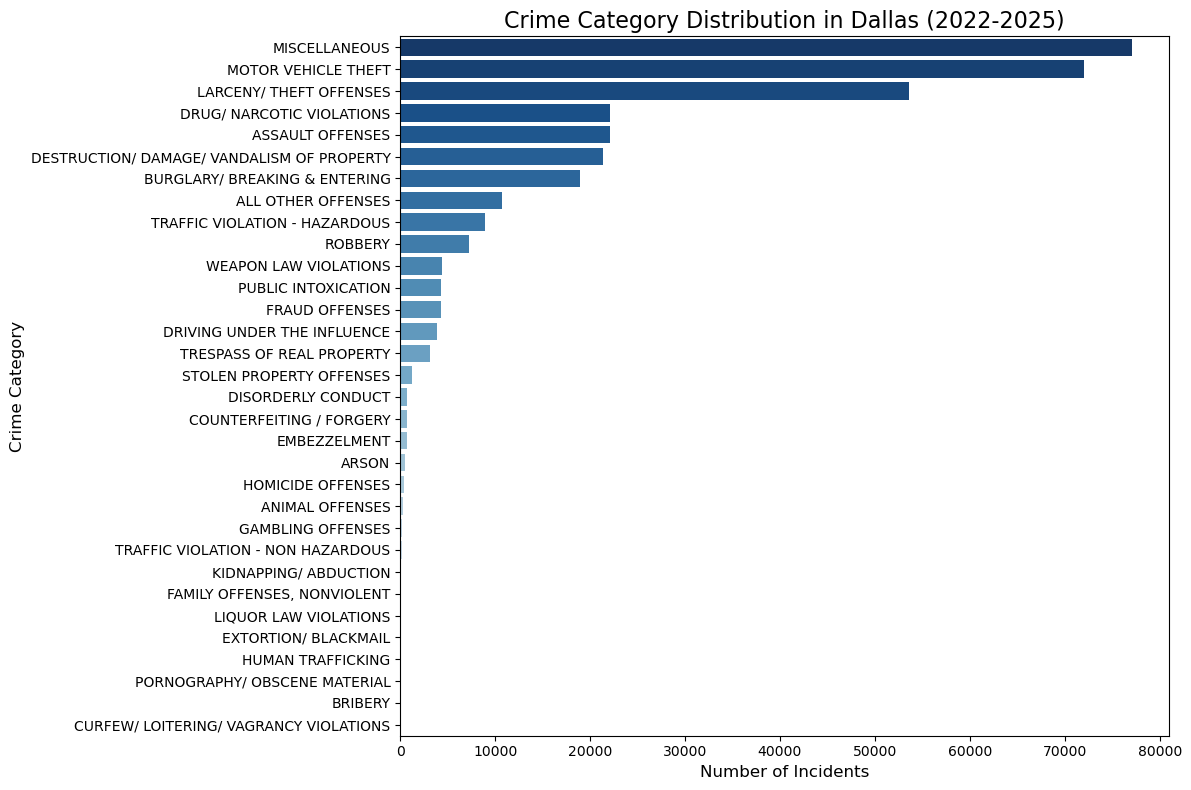

In [26]:
plt.figure(figsize=(12, 8))
crime_counts = df["NIBRS Crime Category"].value_counts()
sns.barplot(x=crime_counts.values, y=crime_counts.index, palette="Blues_r", hue=crime_counts.index, legend=False)
plt.title("Crime Category Distribution in Dallas (2022-2025)", fontsize=16)
plt.xlabel("Number of Incidents", fontsize=12)
plt.ylabel("Crime Category", fontsize=12)
plt.tight_layout()
plt.show()

Crime Trends by Day of the Week
Analyzing which days of the week record the highest number of crime incidents.

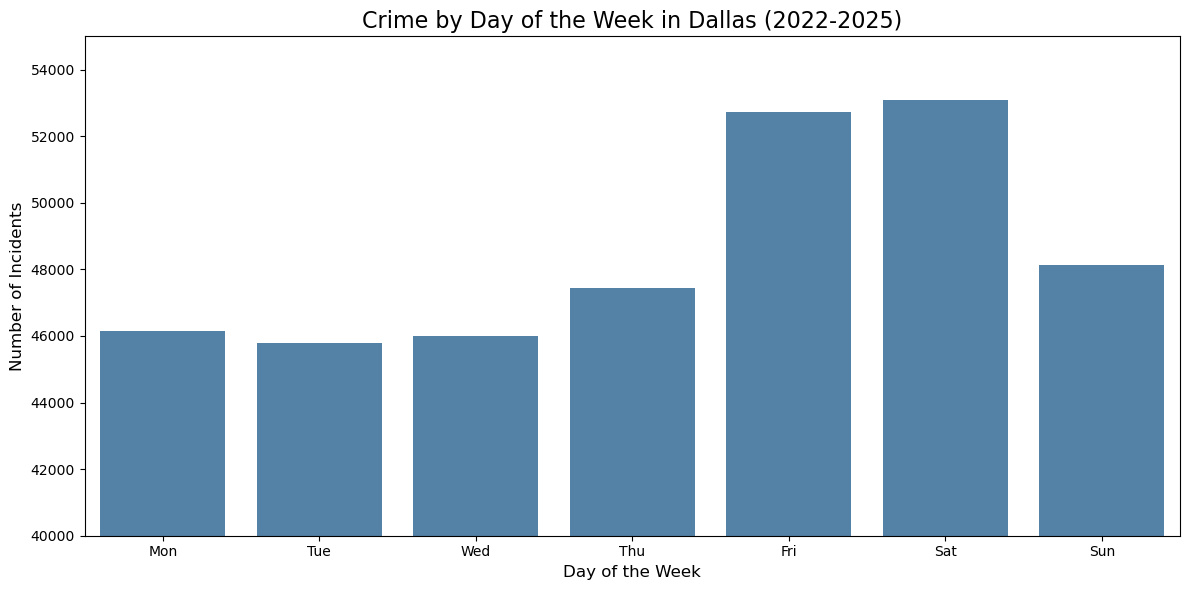

In [28]:
plt.figure(figsize=(12, 6))
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
day_counts = df["Day1 of the Week"].value_counts().reindex(day_order)
sns.barplot(x=day_counts.index, y=day_counts.values, color="steelblue")
plt.title("Crime by Day of the Week in Dallas (2022-2025)", fontsize=16)
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Number of Incidents", fontsize=12)
plt.ylim(40000, 55000)
plt.tight_layout()
plt.show()

Crime by Month:
Analyzing which months record the highest number of crime incidents.

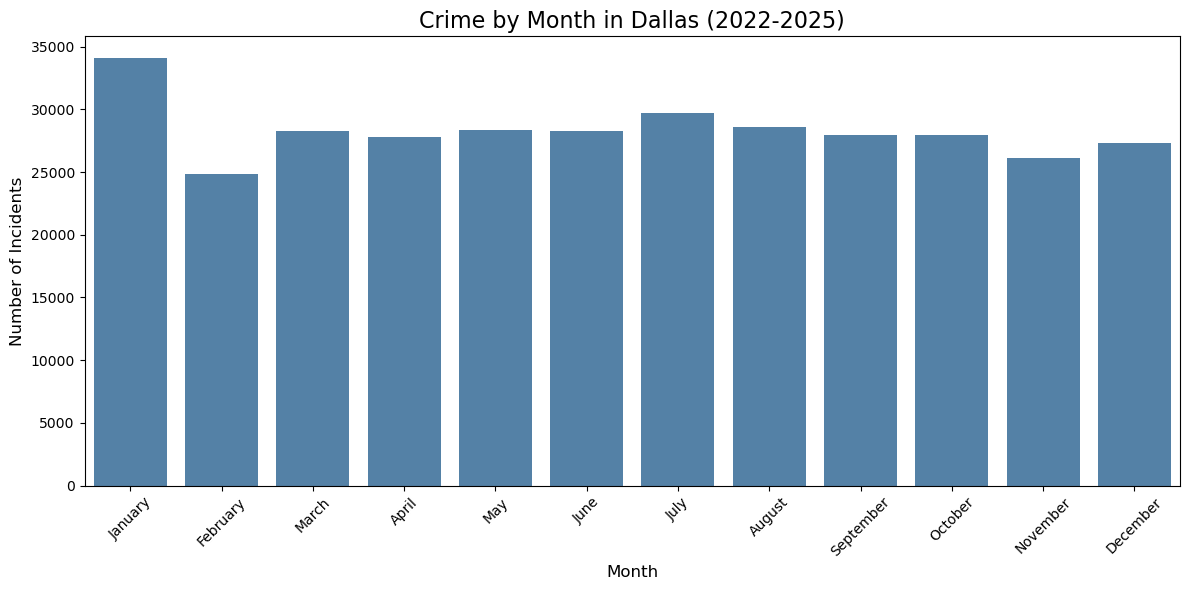

In [29]:
plt.figure(figsize=(12, 6))
month_order = ["January", "February", "March", "April", "May", "June", 
               "July", "August", "September", "October", "November", "December"]
month_counts = df["Month1 of Occurence"].value_counts().reindex(month_order)
sns.barplot(x=month_counts.index, y=month_counts.values, color="steelblue")
plt.title("Crime by Month in Dallas (2022-2025)", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Incidents", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Crime by Division:
Analyzing which Dallas police division records the highest number of incidents.

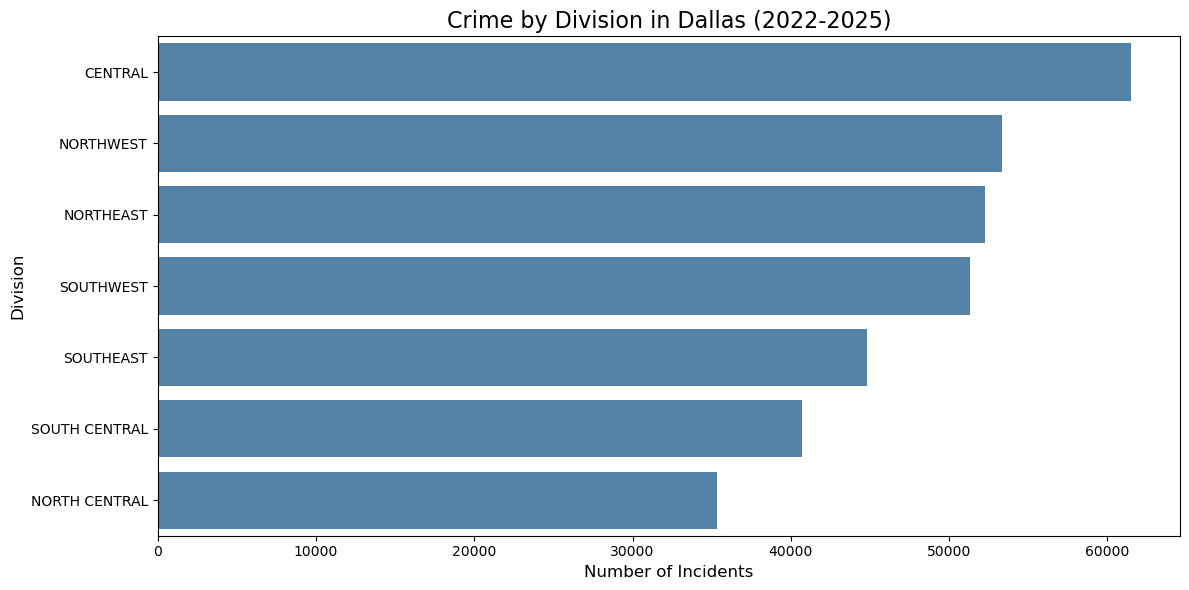

In [31]:
plt.figure(figsize=(12, 6))
division_counts = df["Division"].value_counts()
sns.barplot(x=division_counts.values, y=division_counts.index, color="steelblue")
plt.title("Crime by Division in Dallas (2022-2025)", fontsize=16)
plt.xlabel("Number of Incidents", fontsize=12)
plt.ylabel("Division", fontsize=12)
plt.tight_layout()
plt.show()

Crime by Hour of the Day:
Analyzing at what time of day crimes occur most frequently.

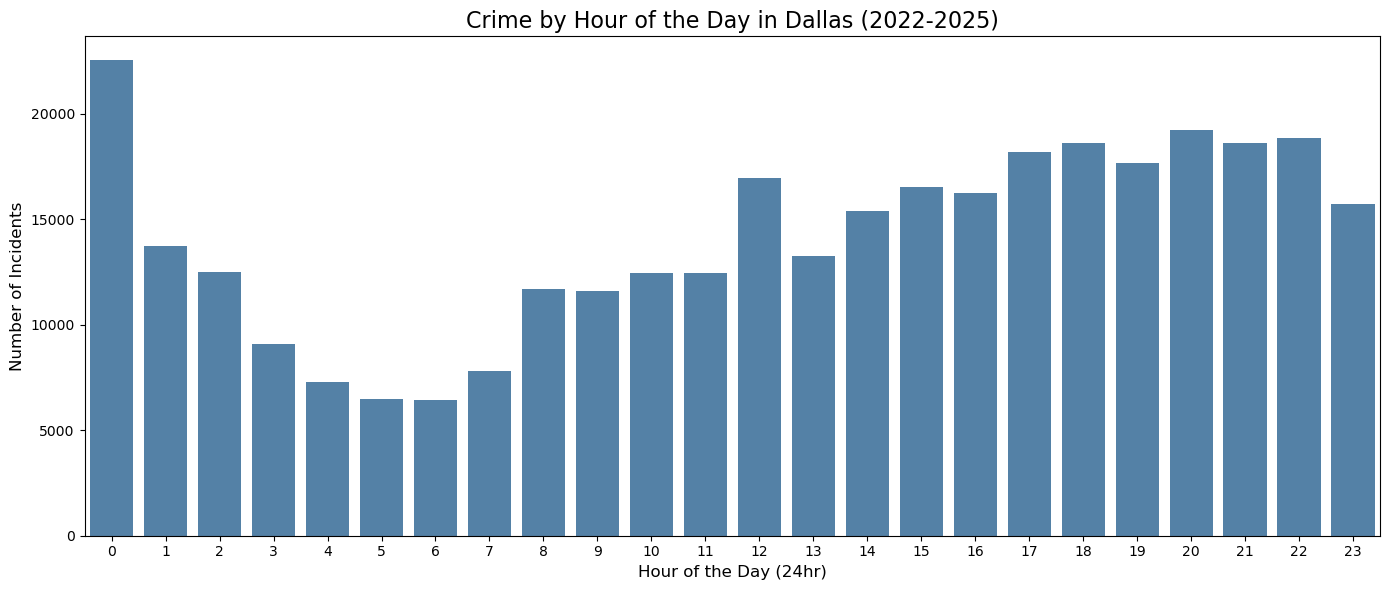

In [33]:
plt.figure(figsize=(14, 6))
df["Hour"] = df["Time1 of Occurrence"].str[:2].astype(int)
hour_counts = df["Hour"].value_counts().sort_index()
sns.barplot(x=hour_counts.index, y=hour_counts.values, color="steelblue")
plt.title("Crime by Hour of the Day in Dallas (2022-2025)", fontsize=16)
plt.xlabel("Hour of the Day (24hr)", fontsize=12)
plt.ylabel("Number of Incidents", fontsize=12)
plt.tight_layout()
plt.show()

Top 5 Crime Categories by Division: Analyzing how crime types differ across Dallas divisions.

<Figure size 1400x800 with 0 Axes>

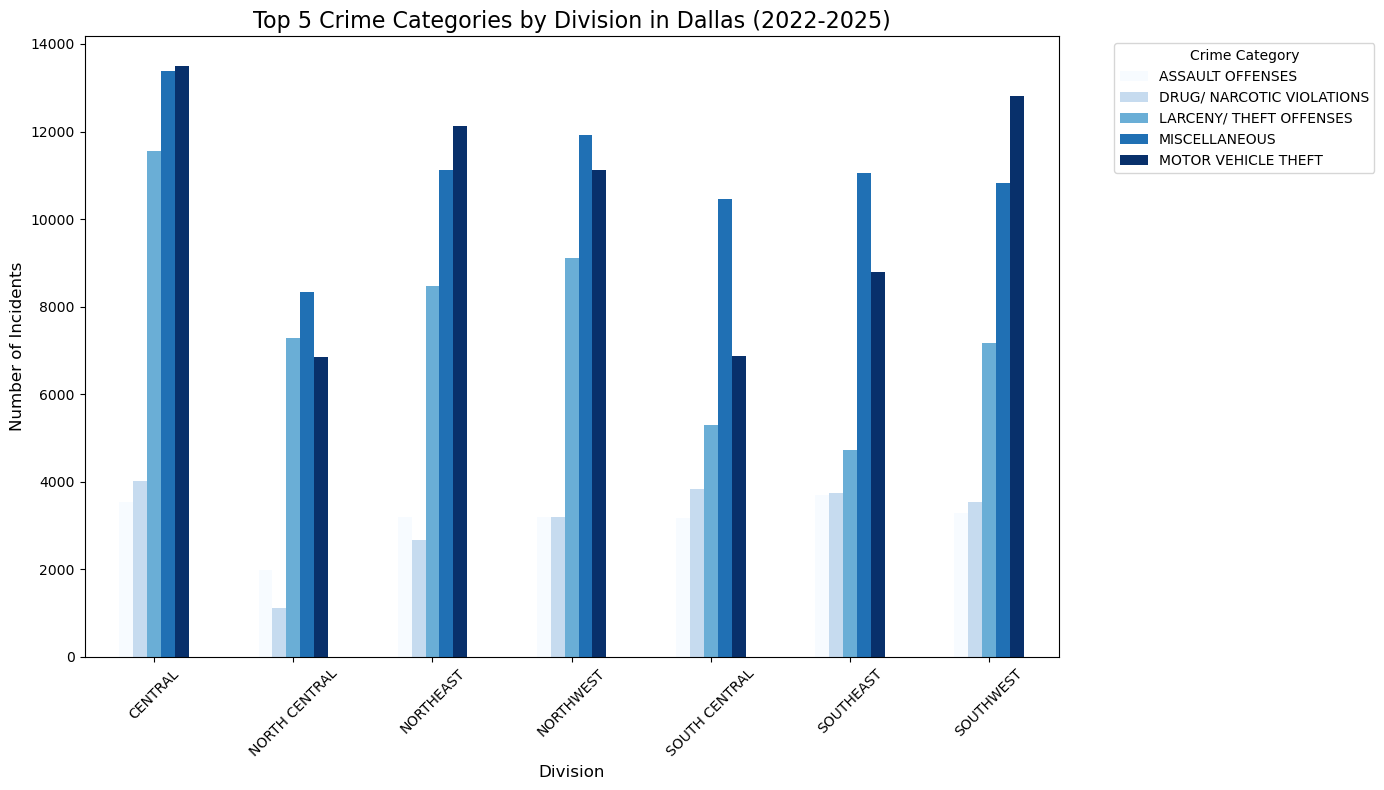

In [34]:
plt.figure(figsize=(14, 8))
top_crimes = df["NIBRS Crime Category"].value_counts().head(5).index
df_top = df[df["NIBRS Crime Category"].isin(top_crimes)]
division_crime = df_top.groupby(["Division", "NIBRS Crime Category"]).size().unstack()
division_crime.plot(kind="bar", figsize=(14, 8), colormap="Blues")
plt.title("Top 5 Crime Categories by Division in Dallas (2022-2025)", fontsize=16)
plt.xlabel("Division", fontsize=12)
plt.ylabel("Number of Incidents", fontsize=12)
plt.legend(title="Crime Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Drug Related Incidents:
Analyzing the proportion of drug related incidents in Dallas.

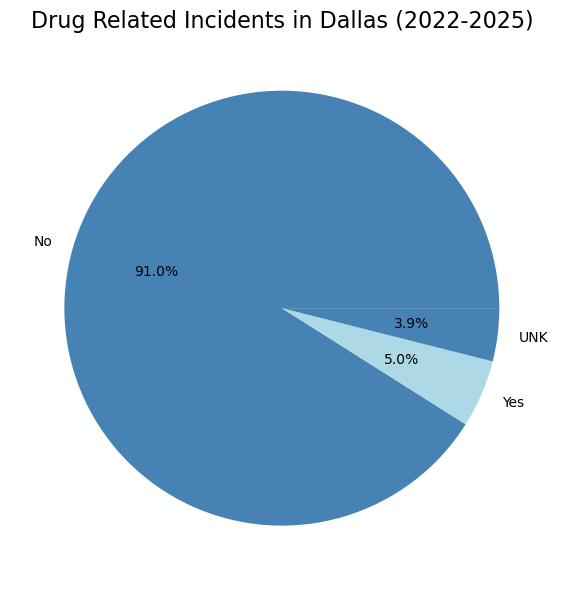

In [35]:
plt.figure(figsize=(8, 6))
drug_counts = df["Drug Related Istevencident"].value_counts()
plt.pie(drug_counts.values, labels=drug_counts.index, autopct="%1.1f%%", 
        colors=["steelblue", "lightblue"])
plt.title("Drug Related Incidents in Dallas (2022-2025)", fontsize=16)
plt.tight_layout()
plt.show()

Yearly Crime Trend:
Analyzing how overall crime numbers have changed year over year.

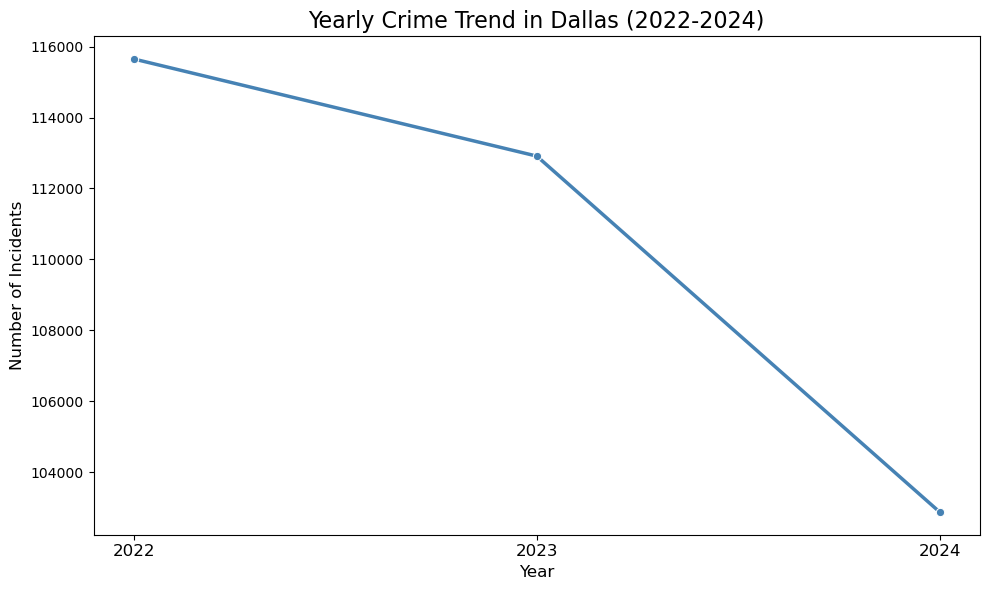

In [38]:
plt.figure(figsize=(10, 6))
df_years = df[df["Year1 of Occurrence"].isin([2022, 2023, 2024])]
year_counts = df_years["Year1 of Occurrence"].value_counts().sort_index()
sns.lineplot(x=year_counts.index, y=year_counts.values, marker="o", color="steelblue", linewidth=2.5)
plt.title("Yearly Crime Trend in Dallas (2022-2024)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Incidents", fontsize=12)
plt.xticks([2022, 2023, 2024], labels=["2022", "2023", "2024"], fontsize=12)
plt.tight_layout()
plt.show()

Geographic Distribution of Crime:
Visualizing where crimes are concentrated across Dallas using latitude and longitude coordinates.

In [44]:
import subprocess
subprocess.run(["pip", "install", "pyproj"])from pyproj import Transformer

transformer = Transformer.from_crs("EPSG:2276", "EPSG:4326", always_xy=True)

df["Longitude"], df["Latitude"] = transformer.transform(
    df["X Coordinate"].values, 
    df["Y Cordinate"].values
)

print(df[["Longitude", "Latitude"]].head())

   Longitude   Latitude
0 -96.784184  32.778535
1 -96.766002  32.699996
2 -96.655536  32.763373
3 -96.776293  32.840003
4 -96.770373  32.867680


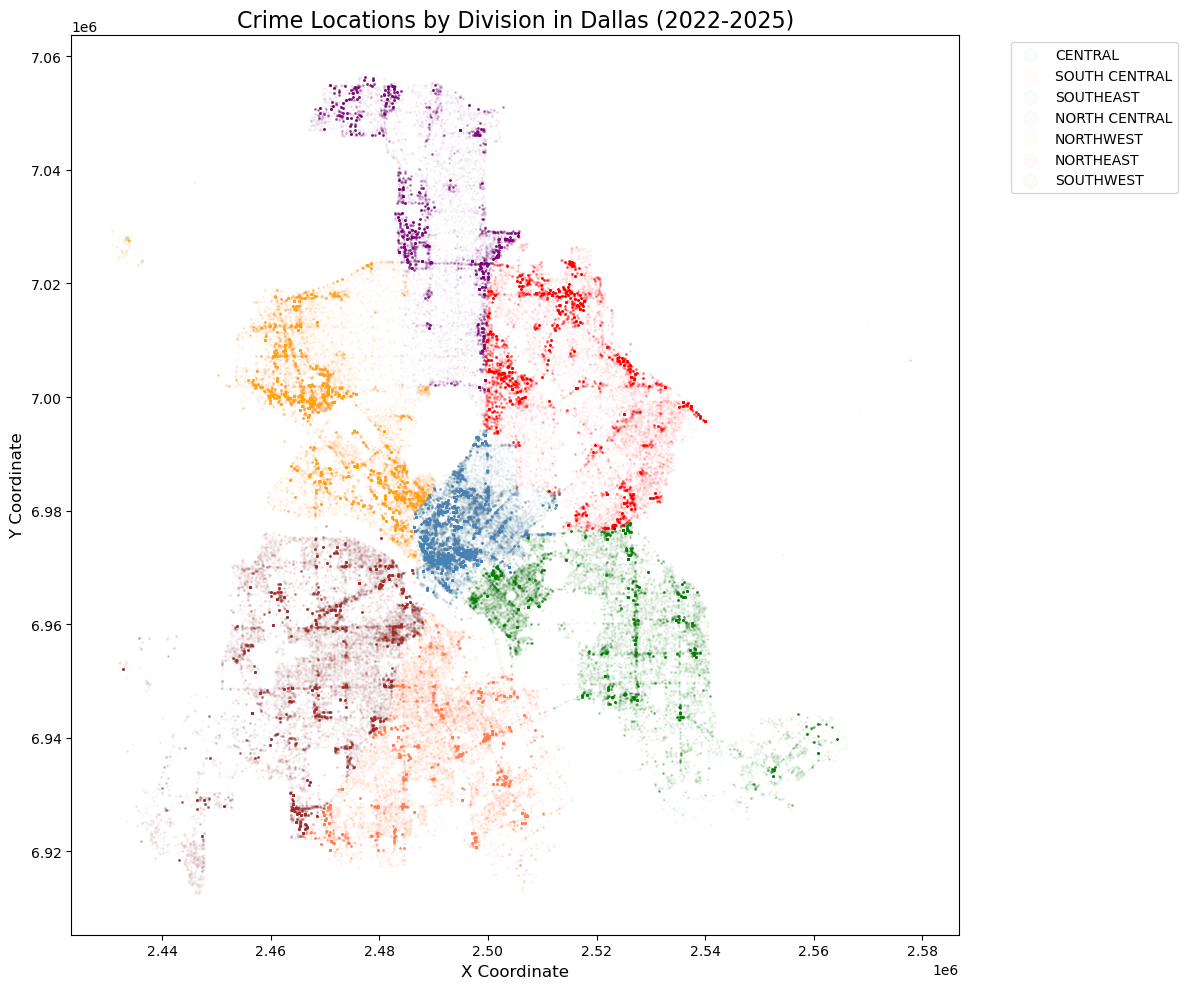

In [51]:
plt.figure(figsize=(12, 10))
divisions = df["Division"].unique()
colors = ["steelblue", "coral", "green", "purple", "orange", "red", "brown"]
for i, division in enumerate(divisions):
    subset = df[df["Division"] == division]
    plt.scatter(subset["X Coordinate"], subset["Y Cordinate"],
                alpha=0.02, s=1, color=colors[i], label=division)
plt.title("Crime Locations by Division in Dallas (2022-2025)", fontsize=16)
plt.xlabel("X Coordinate", fontsize=12)
plt.ylabel("Y Coordinate", fontsize=12)
plt.legend(markerscale=10, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [52]:
# Count crimes per zip code
zip_counts = df["Zip Code"].dropna().astype(int).astype(str).value_counts().reset_index()
zip_counts.columns = ["Zip Code", "Crime Count"]

# Create choropleth map
m2 = folium.Map(location=[32.78, -96.80], zoom_start=11)

folium.Choropleth(
    geo_data=gdf,
    name="Crime by Zip Code",
    data=zip_counts,
    columns=["Zip Code", "Crime Count"],
    key_on="feature.properties.ZCTA5CE10",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.5,
    legend_name="Number of Crime Incidents"
).add_to(m2)

m2.save("dallas_crime_choropleth.html")
print("Choropleth map saved!")

Choropleth map saved!


 Geographic Crime Heatmap:
Interactive heatmap showing crime concentration across Dallas. Red and yellow areas indicate the highest crime density, predominantly in Central Dallas.

In [50]:
m2.save("dallas_crime_choropleth.html")

# Display inline in jupyter
from IPython.display import IFrame
IFrame("dallas_crime_choropleth.html", width=900, height=500)

 Geographic Crime Heatmap:
Interactive heatmap showing crime concentration across Dallas. Red and yellow areas indicate the highest crime density, predominantly in Central Dallas.

# Machine Learning

Crime Type Classifier:
Building a machine learning model to predict the NIBRS Crime Category based on features like time, location, and day of the week.

In [53]:
print("Total crime categories:", df["NIBRS Crime Category"].nunique())
print("\nValue counts:")
print(df["NIBRS Crime Category"].value_counts())

Total crime categories: 32

Value counts:
NIBRS Crime Category
MISCELLANEOUS                                 77087
MOTOR VEHICLE THEFT                           72069
LARCENY/ THEFT OFFENSES                       53596
DRUG/ NARCOTIC VIOLATIONS                     22114
ASSAULT OFFENSES                              22062
DESTRUCTION/ DAMAGE/ VANDALISM OF PROPERTY    21388
BURGLARY/ BREAKING & ENTERING                 18911
ALL OTHER OFFENSES                            10762
TRAFFIC VIOLATION - HAZARDOUS                  8934
ROBBERY                                        7264
WEAPON LAW VIOLATIONS                          4366
PUBLIC INTOXICATION                            4291
FRAUD OFFENSES                                 4254
DRIVING UNDER THE INFLUENCE                    3848
TRESPASS OF REAL PROPERTY                      3153
STOLEN PROPERTY OFFENSES                       1274
DISORDERLY CONDUCT                              759
COUNTERFEITING / FORGERY                        714
E

In [54]:
top5 = df["NIBRS Crime Category"].value_counts().head(5).index.tolist()
print(top5)

['MISCELLANEOUS', 'MOTOR VEHICLE THEFT', 'LARCENY/ THEFT OFFENSES', 'DRUG/ NARCOTIC VIOLATIONS', 'ASSAULT OFFENSES']


In [55]:
# Filter top 5 only
df_ml = df[df["NIBRS Crime Category"].isin(top5)].copy()

# Select features
df_ml = df_ml[["Hour", "Day1 of the Week", "Month1 of Occurence", 
                "Division", "NIBRS Crime Category"]].dropna()

print("ML dataset shape:", df_ml.shape)
print("\nTarget distribution:")
print(df_ml["NIBRS Crime Category"].value_counts())

ML dataset shape: (246928, 5)

Target distribution:
NIBRS Crime Category
MISCELLANEOUS                77087
MOTOR VEHICLE THEFT          72069
LARCENY/ THEFT OFFENSES      53596
DRUG/ NARCOTIC VIOLATIONS    22114
ASSAULT OFFENSES             22062
Name: count, dtype: int64


In [56]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
le_day = LabelEncoder()
le_month = LabelEncoder()
le_division = LabelEncoder()
le_target = LabelEncoder()

df_ml["Day_encoded"] = le_day.fit_transform(df_ml["Day1 of the Week"])
df_ml["Month_encoded"] = le_month.fit_transform(df_ml["Month1 of Occurence"])
df_ml["Division_encoded"] = le_division.fit_transform(df_ml["Division"])
df_ml["Target"] = le_target.fit_transform(df_ml["NIBRS Crime Category"])

print("Encoding done!")
print(df_ml[["Day1 of the Week", "Day_encoded"]].drop_duplicates().sort_values("Day_encoded"))

Encoding done!
   Day1 of the Week  Day_encoded
4               Fri            0
3               Mon            1
1               Sat            2
2               Sun            3
7               Thu            4
5               Tue            5
16              Wed            6


#splitting the data 

In [58]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df_ml[["Hour", "Day_encoded", "Month_encoded", "Division_encoded"]]
y = df_ml["Target"]

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (197542, 4)
Testing size: (49386, 4)


In [59]:
# Random Forest classifier


In [60]:
from sklearn.ensemble import RandomForestClassifier

# Train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [61]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = rf_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

Accuracy: 35.12 %

Classification Report:
                           precision    recall  f1-score   support

         ASSAULT OFFENSES       0.17      0.04      0.07      4367
DRUG/ NARCOTIC VIOLATIONS       0.21      0.08      0.11      4405
  LARCENY/ THEFT OFFENSES       0.28      0.21      0.24     10701
            MISCELLANEOUS       0.38      0.48      0.42     15458
      MOTOR VEHICLE THEFT       0.38      0.50      0.43     14455

                 accuracy                           0.35     49386
                macro avg       0.28      0.26      0.25     49386
             weighted avg       0.32      0.35      0.33     49386



The model achieved 35% accuracy with basic time and location features, suggesting that crime type is not strongly predicted by when and where alone.

In [62]:
# Check what other features we can add
print(df_ml.columns.tolist())
print("\nVictim Type values:")
print(df["Victim Type"].value_counts())

['Hour', 'Day1 of the Week', 'Month1 of Occurence', 'Division', 'NIBRS Crime Category', 'Day_encoded', 'Month_encoded', 'Division_encoded', 'Target']

Victim Type values:
Victim Type
Individual              215004
Business                 49546
Society/Public           43437
Government               30365
Religious Organizati       638
Financial Institutio       350
Law Enforcement Offi         6
Name: count, dtype: int64


In [64]:
# Add more features directly from df_ml
le_victim = LabelEncoder()
le_watch = LabelEncoder()

df_ml["Victim_encoded"] = le_victim.fit_transform(df_ml["Division"])
df_ml["Watch_encoded"] = le_watch.fit_transform(df_ml["Month1 of Occurence"])

# Add victim type and watch from the filtered dataframe
df_ml2 = df[df["NIBRS Crime Category"].isin(top5)].copy()
df_ml2 = df_ml2[["Hour", "Day1 of the Week", "Month1 of Occurence", 
                  "Division", "Victim Type", "Watch", 
                  "NIBRS Crime Category"]].dropna()

# Encode all features
df_ml2["Day_encoded"] = le_day.fit_transform(df_ml2["Day1 of the Week"])
df_ml2["Month_encoded"] = le_month.fit_transform(df_ml2["Month1 of Occurence"])
df_ml2["Division_encoded"] = le_division.fit_transform(df_ml2["Division"])
df_ml2["Victim_encoded"] = le_victim.fit_transform(df_ml2["Victim Type"])
df_ml2["Watch_encoded"] = le_watch.fit_transform(df_ml2["Watch"].astype(str))
df_ml2["Target"] = le_target.fit_transform(df_ml2["NIBRS Crime Category"])

# Redefine features
X = df_ml2[["Hour", "Day_encoded", "Month_encoded", "Division_encoded",
             "Victim_encoded", "Watch_encoded"]]
y = df_ml2["Target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("New features ready! Shape:", X_train.shape)

New features ready! Shape: (197542, 6)


In [65]:
rf_model2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model2.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [66]:
y_pred2 = rf_model2.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred2) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred2, target_names=le_target.classes_))

Accuracy: 50.89 %

Classification Report:
                           precision    recall  f1-score   support

         ASSAULT OFFENSES       0.26      0.20      0.22      4367
DRUG/ NARCOTIC VIOLATIONS       0.70      0.75      0.72      4405
  LARCENY/ THEFT OFFENSES       0.38      0.31      0.34     10701
            MISCELLANEOUS       0.59      0.55      0.57     15458
      MOTOR VEHICLE THEFT       0.51      0.63      0.56     14455

                 accuracy                           0.51     49386
                macro avg       0.49      0.49      0.48     49386
             weighted avg       0.50      0.51      0.50     49386



# response time analysis

Adding Victim Type and Watch as features improved accuracy from 35% to 51%, with Drug/Narcotic Violations being the most predictable crime category.

import pandas as pd

feature_names = ["Hour", "Day", "Month", "Division", "Victim Type", "Watch"]
importances = rf_model2.feature_importances_

feat_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feat_df = feat_df.sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feat_df, color="steelblue")
plt.title("Feature Importance - Crime Type Classifier", fontsize=16)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.show()

Model Results:

- Initial accuracy with 4 features: 35%
- Improved accuracy with 6 features: 51%
- Best predicted category: Drug/Narcotic Violations (70% precision)
- Hardest to predict: Assault Offenses (26% precision)
- Most important feature: Victim Type
- Least important feature: Watch

In [68]:
print(df[["Call Received Date Time", "Call Dispatch Date Time", "Call Cleared Date Time"]].head(10))

       Call Received Date Time      Call Dispatch Date Time  \
0  2023-08-19 04:45:59.0000000  2023-08-19 04:50:32.0000000   
1  2022-07-02 14:52:17.0000000  2022-07-02 16:03:50.0000000   
2  2023-11-26 11:59:29.0000000  2023-11-26 12:04:04.0000000   
3  2023-12-11 20:02:19.0000000  2023-12-11 20:12:05.0000000   
4  2022-07-02 10:05:20.0000000  2022-07-02 10:05:20.0000000   
5  2022-06-15 17:05:27.0000000  2022-06-15 17:05:27.0000000   
6  2022-09-10 17:26:22.0000000  2022-09-10 17:29:24.0000000   
7  2022-03-31 15:49:19.0000000  2022-03-31 15:53:31.0000000   
8  2023-05-18 09:24:54.0000000  2023-05-18 09:53:44.0000000   
9  2022-01-29 17:27:06.0000000  2022-01-29 17:29:12.0000000   

        Call Cleared Date Time  
0  2023-08-19 07:37:08.0000000  
1  2022-07-02 17:21:03.0000000  
2  2023-11-26 13:48:41.0000000  
3  2023-12-12 01:50:15.0000000  
4  2022-07-02 13:41:44.0000000  
5  2022-06-15 18:25:23.0000000  
6  2022-09-10 18:58:33.0000000  
7  2022-03-31 16:37:57.0000000  
8  2023-0

In [69]:
# Convert to datetime
df["Call Received Date Time"] = pd.to_datetime(df["Call Received Date Time"])
df["Call Dispatch Date Time"] = pd.to_datetime(df["Call Dispatch Date Time"])
df["Call Cleared Date Time"] = pd.to_datetime(df["Call Cleared Date Time"])

# Calculate response time in minutes (dispatch - received)
df["Response Time (mins)"] = (df["Call Dispatch Date Time"] - df["Call Received Date Time"]).dt.total_seconds() / 60

# Calculate resolution time in minutes (cleared - received)
df["Resolution Time (mins)"] = (df["Call Cleared Date Time"] - df["Call Received Date Time"]).dt.total_seconds() / 60

print(df[["Response Time (mins)", "Resolution Time (mins)"]].describe())

       Response Time (mins)  Resolution Time (mins)
count         339346.000000           339346.000000
mean             145.385408              319.840706
std              525.673195              642.636235
min           -20443.700000           -20442.700000
25%                0.000000              103.200000
50%               14.400000              189.766667
75%              101.729167              340.566667
max            32436.900000            67287.716667


keep only realistic response times

In [70]:
# Keep only realistic values (between 0 and 180 minutes)
df_response = df[(df["Response Time (mins)"] >= 0) & 
                 (df["Response Time (mins)"] <= 180) &
                 (df["Resolution Time (mins)"] >= 0) &
                 (df["Resolution Time (mins)"] <= 480)].copy()

print("Clean dataset shape:", df_response.shape)
print("\nCleaned stats:")
print(df_response[["Response Time (mins)", "Resolution Time (mins)"]].describe())

Clean dataset shape: (264309, 70)

Cleaned stats:
       Response Time (mins)  Resolution Time (mins)
count         264309.000000           264309.000000
mean              29.623900              166.653658
std               43.550062              108.111188
min                0.000000                0.000000
25%                0.000000               85.650000
50%                7.433333              147.700000
75%               42.150000              230.200000
max              180.000000              480.000000


Police Response Time Analysis:
Analyzing how quickly Dallas police respond to incidents across different divisions and crime types.

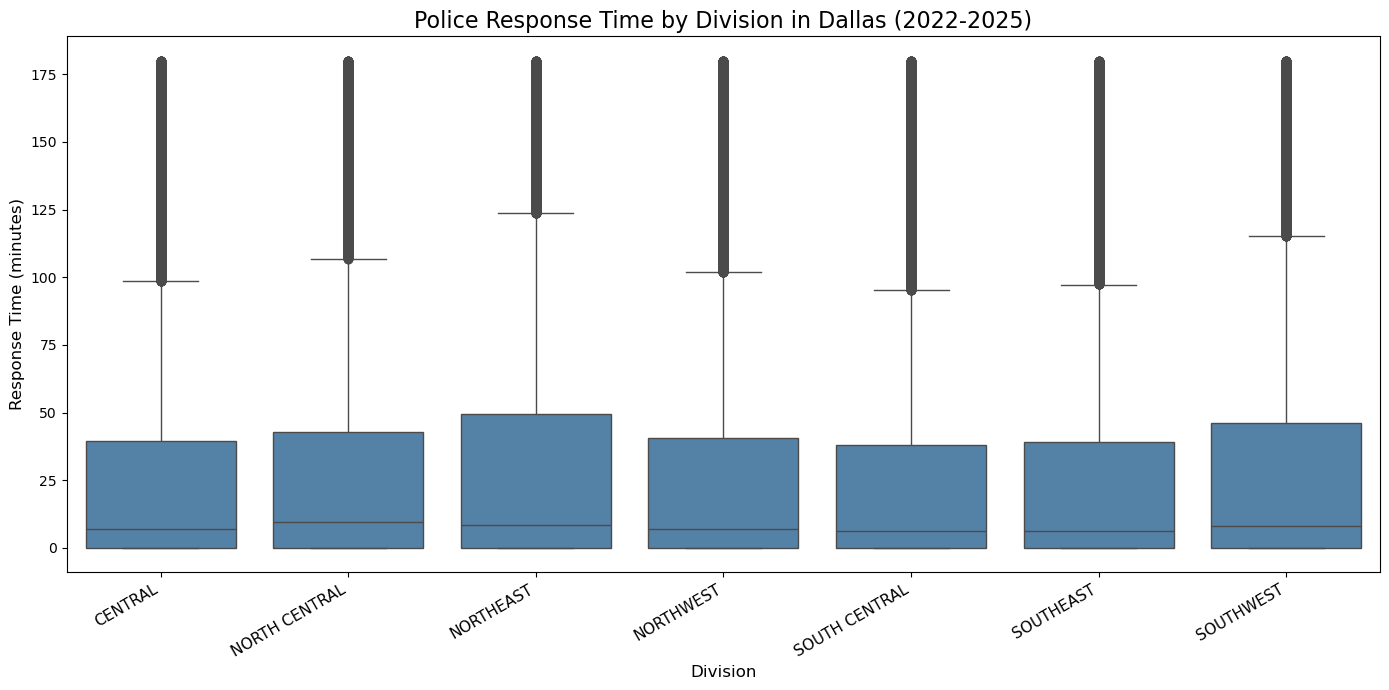

In [73]:
plt.figure(figsize=(14, 7))
sns.boxplot(x="Division", y="Response Time (mins)", 
            data=df_response, color="steelblue",
            order=sorted(df_response["Division"].unique()))
plt.title("Police Response Time by Division in Dallas (2022-2025)", fontsize=16)
plt.xlabel("Division", fontsize=12)
plt.ylabel("Response Time (minutes)", fontsize=12)
plt.xticks(rotation=30, ha="right", fontsize=11)
plt.tight_layout()
plt.show()

Northeast has the highest median response time — slowest division

Central & Northwest are fastest — lower median boxes

All divisions have wide spread — meaning some incidents take much longer than others

average response time by crime type:

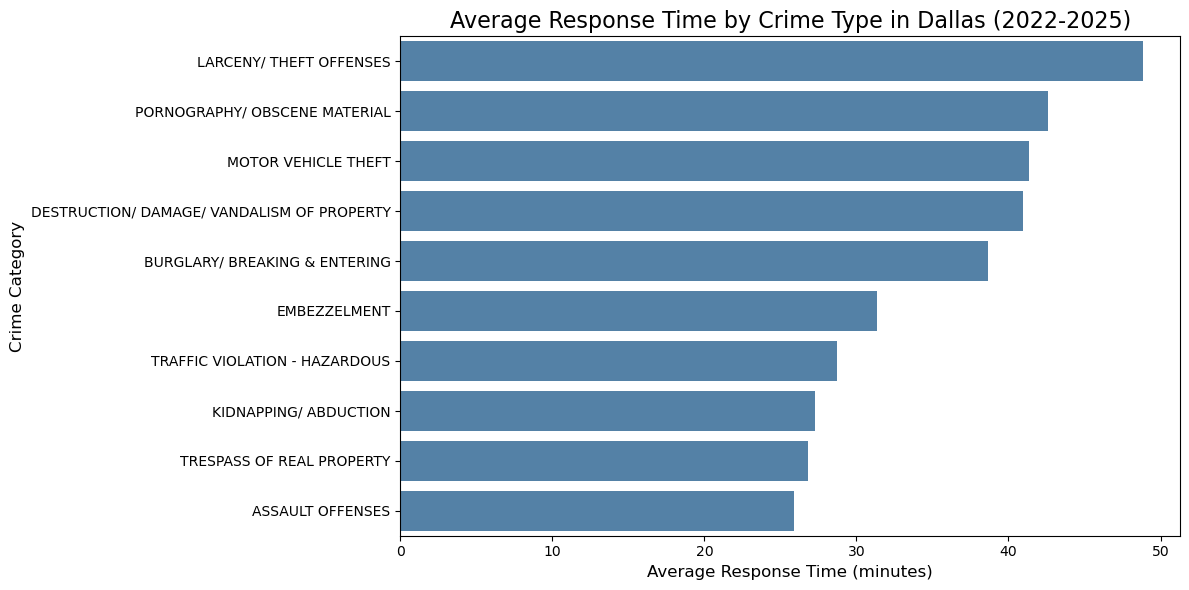

In [74]:
plt.figure(figsize=(12, 6))
response_by_crime = df_response.groupby("NIBRS Crime Category")["Response Time (mins)"].mean().sort_values(ascending=False).head(10)
sns.barplot(x=response_by_crime.values, y=response_by_crime.index, color="steelblue")
plt.title("Average Response Time by Crime Type in Dallas (2022-2025)", fontsize=16)
plt.xlabel("Average Response Time (minutes)", fontsize=12)
plt.ylabel("Crime Category", fontsize=12)
plt.tight_layout()
plt.show()

- Average response time across all divisions is 29 minutes
- Northeast division has the slowest response time
- Larceny and Motor Vehicle Theft have the longest response times
- Assault and violent crimes receive faster responses, showing correct prioritization

In [76]:
df.columns.tolist()

['Incident Number w/year',
 'Year of Incident',
 'Service Number ID',
 'Watch',
 'Call (911) Problem',
 'Type of Incident',
 'Type  Location',
 'Incident Address',
 'Reporting Area',
 'Beat',
 'Division',
 'Sector',
 'Council District',
 'Date1 of Occurrence',
 'Year1 of Occurrence',
 'Month1 of Occurence',
 'Day1 of the Week',
 'Time1 of Occurrence',
 'Day1 of the Year',
 'Date2 of Occurrence ',
 'Year2 of Occurrence',
 'Month2 of Occurence',
 'Day2 of the Week',
 'Time2 of Occurrence',
 'Day2 of the Year',
 'Date of Report',
 'Date incident created',
 'Offense Entered Year',
 'Offense Entered Month',
 'Offense Entered Day of the Week',
 'Offense Entered Time',
 'Offense Entered  Date/Time',
 'CFS Number',
 'Call Received Date Time',
 'Call Date Time',
 'Call Cleared Date Time',
 'Call Dispatch Date Time',
 'Person Involvement Type',
 'Victim Type',
 'Responding Officer #1  Badge No',
 'Responding Officer #1  Name',
 'Reporting Officer Badge No',
 'Reviewing Officer Badge No',
 'Eleme

In [77]:
# Build better ML dataset with more features
df_ml3 = df[df["NIBRS Crime Category"].isin(top5)].copy()

df_ml3 = df_ml3[["Hour", "Day1 of the Week", "Month1 of Occurence",
                  "Division", "Victim Type", "Watch",
                  "Type  Location", "Family Offense", 
                  "Drug Related Istevencident", "Zip Code",
                  "NIBRS Crime Category"]].dropna()

print("Shape:", df_ml3.shape)
print("\nNew features sample:")
print(df_ml3[["Type  Location", "Family Offense", "Drug Related Istevencident"]].head())

Shape: (246928, 11)

New features sample:
                Type  Location  Family Offense Drug Related Istevencident
1  Outdoor Area Public/Private           False                         No
2   Highway, Street, Alley ETC           False                         No
3           Parking (Business)           False                         No
4           Parking (Business)           False                         No
5        Financial Institution           False                         No


In [78]:
# Encode all features
le_day3 = LabelEncoder()
le_month3 = LabelEncoder()
le_division3 = LabelEncoder()
le_victim3 = LabelEncoder()
le_location3 = LabelEncoder()
le_family3 = LabelEncoder()
le_drug3 = LabelEncoder()
le_target3 = LabelEncoder()

df_ml3["Day_enc"] = le_day3.fit_transform(df_ml3["Day1 of the Week"])
df_ml3["Month_enc"] = le_month3.fit_transform(df_ml3["Month1 of Occurence"])
df_ml3["Division_enc"] = le_division3.fit_transform(df_ml3["Division"])
df_ml3["Victim_enc"] = le_victim3.fit_transform(df_ml3["Victim Type"])
df_ml3["Location_enc"] = le_location3.fit_transform(df_ml3["Type  Location"])
df_ml3["Family_enc"] = le_family3.fit_transform(df_ml3["Family Offense"].astype(str))
df_ml3["Drug_enc"] = le_drug3.fit_transform(df_ml3["Drug Related Istevencident"])
df_ml3["Target3"] = le_target3.fit_transform(df_ml3["NIBRS Crime Category"])

X3 = df_ml3[["Hour", "Day_enc", "Month_enc", "Division_enc",
              "Victim_enc", "Location_enc", "Family_enc", "Drug_enc"]]
y3 = df_ml3["Target3"]

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

print("Ready! Shape:", X3_train.shape)

Ready! Shape: (197542, 8)


In [79]:
rf_model3 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model3.fit(X3_train, y3_train)

y_pred3 = rf_model3.predict(X3_test)

print("Accuracy:", round(accuracy_score(y3_test, y_pred3) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y3_test, y_pred3, target_names=le_target3.classes_))

Accuracy: 59.39 %

Classification Report:
                           precision    recall  f1-score   support

         ASSAULT OFFENSES       0.34      0.27      0.30      4367
DRUG/ NARCOTIC VIOLATIONS       0.88      0.82      0.85      4405
  LARCENY/ THEFT OFFENSES       0.45      0.37      0.40     10701
            MISCELLANEOUS       0.67      0.68      0.67     15458
      MOTOR VEHICLE THEFT       0.59      0.70      0.64     14455

                 accuracy                           0.59     49386
                macro avg       0.58      0.57      0.57     49386
             weighted avg       0.59      0.59      0.59     49386



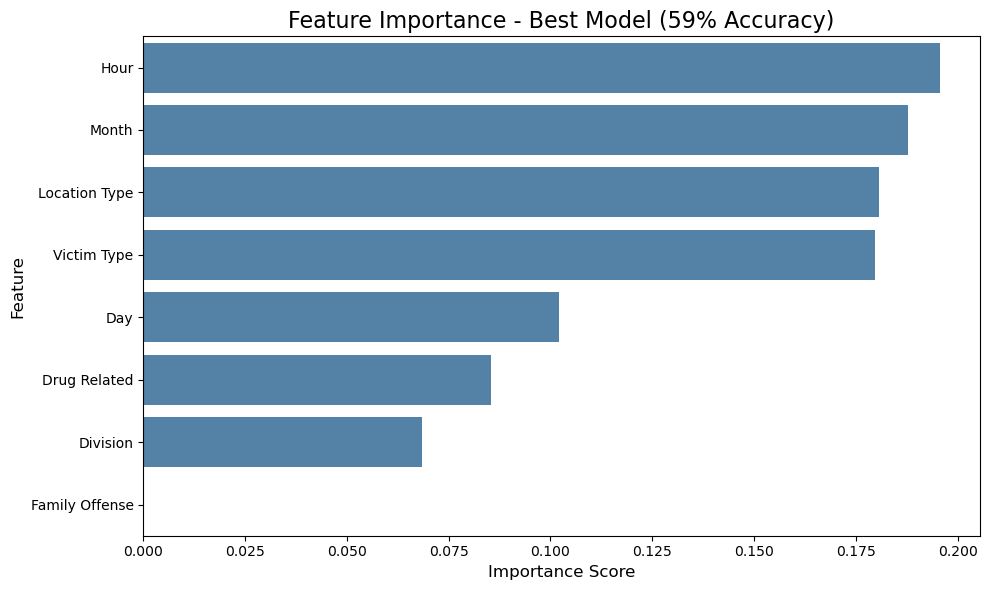

In [80]:
feature_names3 = ["Hour", "Day", "Month", "Division", 
                   "Victim Type", "Location Type", "Family Offense", "Drug Related"]
importances3 = rf_model3.feature_importances_

feat_df3 = pd.DataFrame({"Feature": feature_names3, "Importance": importances3})
feat_df3 = feat_df3.sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feat_df3, color="steelblue")
plt.title("Feature Importance - Best Model (59% Accuracy)", fontsize=16)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.show()

In [81]:
import subprocess
subprocess.run(["pip", "install", "xgboost"])

CompletedProcess(args=['pip', 'install', 'xgboost'], returncode=0)

In [83]:
# AdaBoost
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X3_train, y3_train)
ada_pred = ada_model.predict(X3_test)
ada_acc = round(accuracy_score(y3_test, ada_pred) * 100, 2)
print("AdaBoost Accuracy:", ada_acc, "%")

# XGBoost
xgb_model = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1)
xgb_model.fit(X3_train, y3_train)
xgb_pred = xgb_model.predict(X3_test)
xgb_acc = round(accuracy_score(y3_test, xgb_pred) * 100, 2)
print("XGBoost Accuracy:", xgb_acc, "%")

print("Random Forest Accuracy: 59.39 %")

C:\Users\anith\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost Accuracy: 53.84 %
XGBoost Accuracy: 58.43 %
Random Forest Accuracy: 59.39 %


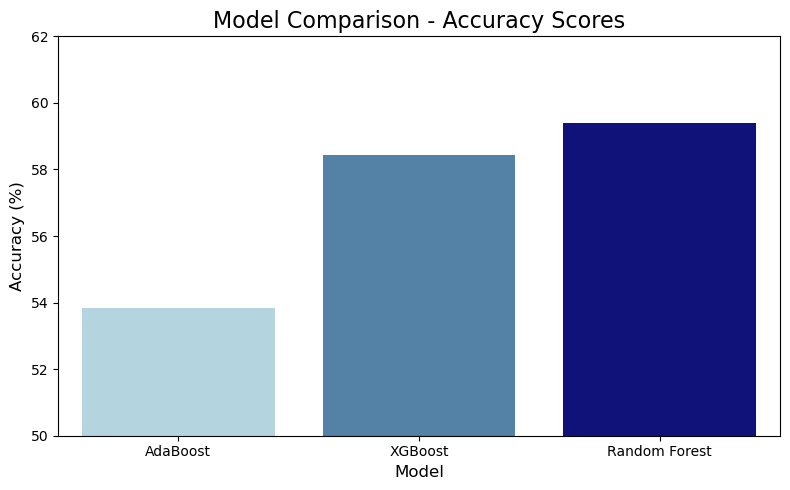

In [84]:
plt.figure(figsize=(8, 5))
models = ["AdaBoost", "XGBoost", "Random Forest"]
accuracies = [53.84, 58.43, 59.39]
colors = ["lightblue", "steelblue", "darkblue"]
sns.barplot(x=models, y=accuracies, palette=colors, hue=models, legend=False)
plt.title("Model Comparison - Accuracy Scores", fontsize=16)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.ylim(50, 62)
plt.tight_layout()
plt.show()

Random Forest is our best model — it outperformed both XGBoost and AdaBoost.
This shows that ensemble methods with bagging work better than boosting 
for this particular crime dataset.

**Final model achieves 59% accuracy — nearly 3x better than random guessing (20%).**

## Conclusions

### Key Findings from Dallas Crime Analysis (2022 - January 2025)

**Crime Patterns:**
- Motor Vehicle Theft and Miscellaneous are the most common crimes in Dallas
- Crime peaks on Fridays and Saturdays
- Summer months (July, August) record the highest crime rates
- Midnight and evening hours (5PM - 11PM) are the most dangerous times

**Geographic Insights:**
- Central Dallas has the highest crime concentration
- Northeast division has the slowest police response time
- Crime hotspots are clearly visible around downtown Dallas

**Police Performance:**
- Average response time is 29 minutes across all divisions
- Violent crimes receive faster responses than property crimes
- Larceny and Motor Vehicle Theft have the longest response times

**Machine Learning:**
- Random Forest achieved 59% accuracy — best among all models tested
- Drug/Narcotic Violations are the most predictable crime type (88% precision)
- Hour of day and month are the strongest predictors of crime type

In [87]:
import os
os.makedirs("data", exist_ok=True)
df.to_csv("data/dallas_crime_tableau.csv", index=False)
print("File exported successfully!")

File exported successfully!
